In [3]:
%pip install -U langchain-google-genai


  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 8.3 MB/s  0:00:00
   ---------------------------------------- 0.0/572.1 kB ? eta -:--:--
   ---------------------------------------- 572.1/572.1 kB 10.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 10.3 MB/s  0:00:00
Using cached typing_inspection-0.4.4-py3-none-any.whl (14 kB)
Using cached typing_extensions-4.16.0-py3-none-any.whl (45 kB)

  Attempting uninstall: typing-extensions

   ---- ----------------------------------- 1/9 [typing-extensions]
    Found existing installation: typing_extensions 4.14.1
   ---- ----------------------------------- 1/9 [typing-extensions]
    Uninstalling typing_extensions-4.14.1:
   ---- --

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-cloud-auth 0.1.4 requires pydantic<2.0, but you have pydantic 2.13.5 which is incompatible.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.6.6 which is incompatible.
langchain-community 0.3.27 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.6.6 which is incompatible.
langchain-huggingface 0.3.1 requires langchain-core<1.0.0,>=0.3.70, but you have langchain-core 1.6.6 which is incompatible.
langchain-openai 0.3.29 requires langchain-core<1.0.0,>=0.3.74, but you have langchain-core 1.6.6 which is incompatible.
langchain-text-splitters 0.3.9 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.6.6 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 wh

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings, GoogleGenerativeAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_core.tools.retriever import create_retriever_tool
from pypdf import PdfReader
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
import os

In [72]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.8-flash",
    google_api_key="Your-API-Key",
    temperature=0.7
)

In [10]:
%pip install -U pymupdf


   ---------------------------------------- 0.0/19.8 MB ? eta -:--:--
   -- ------------------------------------- 1.0/19.8 MB 6.3 MB/s eta 0:00:03
   -- ------------------------------------- 1.0/19.8 MB 6.3 MB/s eta 0:00:03
   ---- ----------------------------------- 2.4/19.8 MB 4.1 MB/s eta 0:00:05
   ------ --------------------------------- 3.4/19.8 MB 4.3 MB/s eta 0:00:04
   --------- ------------------------------ 4.7/19.8 MB 4.7 MB/s eta 0:00:04
   ------------ --------------------------- 6.0/19.8 MB 5.1 MB/s eta 0:00:03
   --------------- ------------------------ 7.9/19.8 MB 5.5 MB/s eta 0:00:03
   ------------------- -------------------- 9.7/19.8 MB 5.9 MB/s eta 0:00:02
   ----------------------- ---------------- 11.5/19.8 MB 6.3 MB/s eta 0:00:02
   --------------------------- ------------ 13.6/19.8 MB 6.7 MB/s eta 0:00:01
   ------------------------------- -------- 15.7/19.8 MB 7.0 MB/s eta 0:00:01
   ----------------------------------- ---- 17.8/19.8 MB 7.3 MB/s eta 0:00:01
 

In [15]:
loader = PyMuPDFLoader("doc/AIC rag doc.pdf")
docs = loader.load()

In [16]:
print(docs)

[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-09-02T20:09:02+05:30', 'source': 'doc/AIC rag doc.pdf', 'file_path': 'doc/AIC rag doc.pdf', 'total_pages': 30, 'format': 'PDF 1.7', 'title': 'Microsoft Word - AIC_Agent3_Ecommerce_Solution_Playbook', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-09-02T20:09:02+05:30', 'trapped': '', 'modDate': "D:20260902200902+05'30'", 'creationDate': "D:20260902200902+05'30'", 'page': 0}, page_content='AIC | AI Agent 3 — E-commerce Solution Playbook \nUse recommendations only after Agent 2 has identified the anomaly and supported cause. Validate high-cost actions with experiments. \nE-COMMERCE \nSOLUTION PLAYBOOK \nRAG Knowledge Base for AI Agent 3 \nA 30-page anomaly-to-action intervention handbook designed for solution generation in the AIC e-commerce \nanalytics architecture. \nAI AGENT 1  →  ANOMALY     |     AI AGENT 2  →  CAUSE     |     AI AGENT 3  →  SOLUTION \nPURPOSE\nGive Agent 3

In [17]:
print(len(docs))
print(docs[0])
print(docs[0].page_content)
print(docs[0].metadata)

30
page_content='AIC | AI Agent 3 — E-commerce Solution Playbook 
Use recommendations only after Agent 2 has identified the anomaly and supported cause. Validate high-cost actions with experiments. 
E-COMMERCE 
SOLUTION PLAYBOOK 
RAG Knowledge Base for AI Agent 3 
A 30-page anomaly-to-action intervention handbook designed for solution generation in the AIC e-commerce 
analytics architecture. 
AI AGENT 1  →  ANOMALY     |     AI AGENT 2  →  CAUSE     |     AI AGENT 3  →  SOLUTION 
PURPOSE
Give Agent 3 concrete, efficient, cause-matched interventions — including execution steps, guardrails, 
metrics and experiment logic — instead of generic business advice. 
Edition: September 2026  •  Project: AIC  •  Domain: E-commerce / Marketplace Analytics' metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-09-02T20:09:02+05:30', 'source': 'doc/AIC rag doc.pdf', 'file_path': 'doc/AIC rag doc.pdf', 'total_pages': 30, 'format': 'PDF 1.7', 'title': 'Microsoft Word - A

In [18]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [19]:
len(chunks)

112

In [20]:
embedding_model = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    google_api_key="Your-api-key",
    batch_size = 20
)


import time
from langchain_community.vectorstores import FAISS

vectordb = None

for i, chunk in enumerate(chunks):
    for attempt in range(3):
        try:
            if vectordb is None:
                vectordb = FAISS.from_documents(
                    [chunk], embedding_model
                )
            else:
                vectordb.add_documents([chunk])

            break

        except Exception as e:
            if "429" not in str(e) or attempt == 2:
                raise

            print("Rate limit reached. Waiting 60 seconds...")
            time.sleep(60)

    vectordb.save_local("./faiss_db")
    print(f"Processed {i + 1}/{len(chunks)} chunks")

    time.sleep(1)

print("FAISS vector store saved successfully!")

Processed 1/112 chunks
Processed 2/112 chunks
Processed 3/112 chunks
Processed 4/112 chunks
Processed 5/112 chunks
Processed 6/112 chunks
Processed 7/112 chunks
Processed 8/112 chunks
Processed 9/112 chunks
Processed 10/112 chunks
Processed 11/112 chunks
Processed 12/112 chunks
Processed 13/112 chunks
Processed 14/112 chunks
Processed 15/112 chunks
Processed 16/112 chunks
Processed 17/112 chunks
Processed 18/112 chunks
Processed 19/112 chunks
Processed 20/112 chunks
Processed 21/112 chunks
Processed 22/112 chunks
Processed 23/112 chunks
Processed 24/112 chunks
Processed 25/112 chunks
Processed 26/112 chunks
Processed 27/112 chunks
Processed 28/112 chunks
Processed 29/112 chunks
Processed 30/112 chunks
Processed 31/112 chunks
Processed 32/112 chunks
Processed 33/112 chunks
Processed 34/112 chunks
Processed 35/112 chunks
Processed 36/112 chunks
Processed 37/112 chunks
Processed 38/112 chunks
Processed 39/112 chunks
Processed 40/112 chunks
Processed 41/112 chunks
Processed 42/112 chunks
P

In [21]:
retriever = vectordb.as_retriever(search_type='similarity', search_kwargs={'k':4})
# search_kwargs={'k':4} this denotes we need 4 such similar vectors as query.

In [22]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)
    
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [42]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [43]:
Anomaly = [{'anomaly_id': 'spend_anomaly_1',
  'hypothesis': 'The sharp isolated spike in average spend per customer on day 14 was primarily driven by an increase in the average order value, supported by higher average item prices and order volumes during the anomaly period.',
  'is_ambiguos': 'No'},
 {'anomaly_id': 'cust_anomaly_1',
  'hypothesis': 'The dramatic surge in daily_customers from day 300 to 302 was primarily driven by a massive spike in new_customers, which surged alongside an increase in returning_customers during the same period.',
  'is_ambiguos': 'No'},
 {'anomaly_id': 'gmv_anomaly_1',
  'hypothesis': 'The spike in GMV per active seller on day 381 was driven by an increase in average order value and units sold per seller, supported by higher average item prices during that period.',
  'is_ambiguos': 'No'},
 {'anomaly_id': 'rev_anomaly_1',
  'hypothesis': 'The extreme spike in daily_gmv between day 300 and 303 was primarily driven by a significant increase in daily_customers and orders_per_customer, supported by a rise in average_order_value due to higher average_item_price.',
  'is_ambiguos': 'No'},
 {'anomaly_id': 'seller_anomaly_1',
  'hypothesis': 'The spike in seller_count on days 300 and 301 is primarily driven by a significant simultaneous increase in both new_sellers and active_sellers, indicating a temporary surge in platform seller engagement and acquisition during this period.',
  'is_ambiguos': 'No'}]

In [52]:
from typing import TypedDict, Any

In [62]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    anomalies: Anomaly

In [67]:
def chat_node(state: ChatState):

    anomalies = state["anomalies"]

    prompt = f"""
    Using the PDF notes, provide solutions for the following anomalies:

    {anomalies}
    """

    messages = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

In [68]:
tool_node = ToolNode(tools)

In [69]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

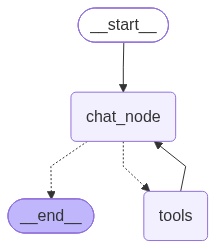

In [70]:
chatbot

In [71]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content="Analyze the anomalies provided in the chat state and, "
                    "using the information from the PDF notes through the RAG tool, "
                    "identify the likely root cause of each anomaly and provide "
                    "a clear, actionable solution for each one. "
                    "Base your recommendations only on the information available "
                    "in the PDF notes and the provided anomaly hypotheses."
            )
        ],
        "anomalies": Anomaly
    }
)

RemoteProtocolError: Server disconnected without sending a response.